# CNN - VNINDEX

## Descriptions
1. Features: ["close"]
1. Target: "close"
1. Timeshift: 40
1. Forecast horizon: 1

## Deploy TensorBoard

In [3]:
# tensorboard --logdir=src/model/lightning_logs/

## Import libraries

In [4]:
import os
import sys
import pandas as pd
import lightning as L
import torch.nn as nn
import torch
from torch.optim import Adam
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tsfresh.utilities.dataframe_functions import (
    roll_time_series,
)
from tsfresh import extract_features, select_features
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import ComprehensiveFCParameters
import matplotlib.pylab as plt
from sklearn.preprocessing import MinMaxScaler
from lightning.pytorch.callbacks import EarlyStopping
from dataclasses import asdict

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from logger.logger import Logger
from utils.constants import FEATURE_SELECTION_LOG_FILE_BASE
from dtos.config_dtos.config_dto import ConfigDto
from tabular_database_driver.postgre_sql_driver import PostgreSQLDriver
from dtos.tabular_database_driver_dtos.postgre_sql_connection_dto import (
    PostgreSQLConnectionDto,
)
from utils.enums import (
    LossFunctionType,
    ModelAchitectureType,
    OptimizerType,
    ScalerType,
)

## Parameters

In [5]:
RANDOM_SEED = 18

In [6]:
MAX_TIMESHIFT = 5
MIN_TIMESHIFT = 5

In [7]:
FORECAST_HORIZON = 1

In [8]:
COLUMN_ID = "stock"
TARGET_COLUMN = "close"
DATE_COLUMN = "date"
FEATURE_COLUMNS = ["close"]

In [9]:
# Inclusive
TRAIN_RANGE = ("2000-01-01", "2021-12-31")
VALIDATION_RANGE = ("2022-01-01", "2023-12-31")
TEST_RANGE = ("2024-01-01", "2026-02-26")

In [10]:
OUTPUT_SIZE = 1

## Hyper Parameters

In [11]:
MAX_EPOCHS = 1000
LEARNING_RATE = 0.000005
PATIENCE = 100
BATCH_SIZE = 32

## Start

### Get data

In [12]:
my_logger = Logger(file_name=f"{FEATURE_SELECTION_LOG_FILE_BASE}/vn_index/test")

In [13]:
my_connection_model = PostgreSQLConnectionDto(
    logger=my_logger,
    host=os.getenv("POSTGRES_HOST"),
    user=os.getenv("POSTGRES_USER"),
    password=os.getenv("POSTGRES_PASSWORD"),
    port=os.getenv("POSTGRES_PORT"),
    database=os.getenv("GOLD_POSTGRES_DATABASE"),
)

In [14]:
my_postgresql_driver = PostgreSQLDriver(logger=my_logger)
my_postgresql_driver.connect(my_connection_model)

<DatabaseExecutionStatus.SUCCESS: 'success'>

In [15]:
vn_index_df = my_postgresql_driver.select(
    schema_name="stock_market", table_name="vn_index"
)

In [16]:
dtype_map = {
    "date": str,
    "open": float,
    "high": float,
    "low": float,
    "close": float,
    "matching_volume": float,
}

vn_index_df = (
    vn_index_df.astype(dtype_map)
    .dropna(subset=["close"])
    .sort_values(by=["date"])
    .reset_index(drop=True)
)

In [17]:
vn_index_df

,date,open,high,low,close,adjust,change,percent_change,matching_volume,matching_value,negotiate_volume,negotiate_value,number_of_buy_orders,buy_volume,average_volume_per_buy_order,number_of_sell_orders,sell_volume,average_volume_per_sell_order,net_volume
0,2008-03-07,640.140,640.140,640.140,640.140,640.14,28.97,4.74,8.169220e+06,515253831000.0,350040.0,29103040000.0,26816.0,5.268141e+07,1965.0,3448.0,9.057040e+06,2627.0,4.362437e+07
1,2008-03-08,646.190,646.190,646.190,646.190,646.1899999999999,25.363333333333333,4.1066666666666665,1.314382e+07,829832099333.3333,769057.0,45944657000.0,27442.0,5.068024e+07,1852.3333333333333,7486.0,1.712815e+07,2464.0,3.355209e+07
2,2008-03-09,652.240,652.240,652.240,652.240,652.24,21.756666666666664,3.4733333333333336,1.811842e+07,1144410367666.6665,1188073.0,62786274000.0,28068.0,4.867907e+07,1739.6666666666667,11523.0,2.519927e+07,2301.0,2.347980e+07
3,2008-03-10,658.290,658.290,658.290,658.290,658.29,18.15,2.84,2.309302e+07,1458988636000.0,1607090.0,79627891000.0,28694.0,4.667790e+07,1627.0,15561.0,3.327038e+07,2138.0,1.340752e+07
4,2008-03-11,638.710,638.710,638.710,638.710,638.71,-19.58,-2.97,1.384280e+07,837466500000.0,226000.0,12099600000.0,14464.0,1.933131e+07,1337.0,17910.0,2.811427e+07,1570.0,-8.782960e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6561,2026-02-22,1832.317,1859.236,1829.801,1856.535,1856.535,33.44499999999999,1.837,7.158068e+08,22272405365000.0,23581058.0,792440247700.0,476711.0,1.233848e+09,2591.3,393692.0,1.198445e+09,3047.9,3.540296e+07
6562,2026-02-23,1833.900,1863.130,1833.900,1860.140,1860.14,36.05,1.98,7.313611e+08,22646206050000.0,23192200.0,777430868000.0,486603.0,1.253004e+09,2575.0,401281.0,1.213944e+09,3025.0,3.906029e+07
6563,2026-02-24,1862.180,1867.690,1849.600,1867.620,1867.62,7.48,0.4,9.667547e+08,31205940310000.0,22413147.0,779573446300.0,598087.0,1.575227e+09,2634.0,507471.0,1.648273e+09,3248.0,-7.304628e+07
6564,2026-02-25,1869.490,1876.010,1855.890,1860.910,1860.91,-6.71,-0.36,1.083635e+09,35678521520000.0,62225450.0,1856894317550.0,694266.0,1.862364e+09,2682.0,597096.0,1.892734e+09,3170.0,-3.036983e+07


In [18]:
vn_index_df_close = vn_index_df[[DATE_COLUMN] + FEATURE_COLUMNS]
vn_index_df_close

,date,close
0,2008-03-07,640.140
1,2008-03-08,646.190
2,2008-03-09,652.240
3,2008-03-10,658.290
4,2008-03-11,638.710
...,...,...
6561,2026-02-22,1856.535
6562,2026-02-23,1860.140
6563,2026-02-24,1867.620
6564,2026-02-25,1860.910


In [19]:
vn_index_df_close.loc[:, "stock"] = "vn_index"
vn_index_df_close

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_3620\2662759176.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vn_index_df_close.loc[:, "stock"] = "vn_index"


,date,close,stock
0,2008-03-07,640.140,vn_index
1,2008-03-08,646.190,vn_index
2,2008-03-09,652.240,vn_index
3,2008-03-10,658.290,vn_index
4,2008-03-11,638.710,vn_index
...,...,...,...
6561,2026-02-22,1856.535,vn_index
6562,2026-02-23,1860.140,vn_index
6563,2026-02-24,1867.620,vn_index
6564,2026-02-25,1860.910,vn_index


In [20]:
input_df = vn_index_df_close

### Roll time series

In [21]:
input_df_rolled = roll_time_series(
    input_df,
    column_id=COLUMN_ID,
    column_sort=DATE_COLUMN,
    max_timeshift=MAX_TIMESHIFT,
    min_timeshift=MIN_TIMESHIFT,
)
input_df_rolled

Rolling: 100%|██████████| 50/50 [00:03<00:00, 12.50it/s]


,date,close,stock,id
2376,2008-03-07,640.140,vn_index,"(vn_index, 2008-03-12)"
2377,2008-03-08,646.190,vn_index,"(vn_index, 2008-03-12)"
2378,2008-03-09,652.240,vn_index,"(vn_index, 2008-03-12)"
2379,2008-03-10,658.290,vn_index,"(vn_index, 2008-03-12)"
2380,2008-03-11,638.710,vn_index,"(vn_index, 2008-03-12)"
...,...,...,...,...
39361,2026-02-22,1856.535,vn_index,"(vn_index, 2026-02-26)"
39362,2026-02-23,1860.140,vn_index,"(vn_index, 2026-02-26)"
39363,2026-02-24,1867.620,vn_index,"(vn_index, 2026-02-26)"
39364,2026-02-25,1860.910,vn_index,"(vn_index, 2026-02-26)"


### Extract features

In [22]:
X = extract_features(
    input_df_rolled.drop(COLUMN_ID, axis=1),
    column_id="id",
    column_sort=DATE_COLUMN,
    impute_function=impute,
    default_fc_parameters=ComprehensiveFCParameters(),
)

Feature Extraction: 100%|██████████| 50/50 [00:46<00:00,  1.07it/s]


In [23]:
X

close__variance_larger_than_standard_deviation  \
vn_index 2008-03-12                                             1.0   
         2008-03-13                                             1.0   
         2008-03-14                                             1.0   
         2008-03-15                                             1.0   
         2008-03-16                                             1.0   
...                                                             ...   
         2026-02-22                                             1.0   
         2026-02-23                                             1.0   
         2026-02-24                                             1.0   
         2026-02-25                                             1.0   
         2026-02-26                                             1.0   

                     close__has_duplicate_max  close__has_duplicate_min  \
vn_index 2008-03-12                       0.0                       0.0   
         2008-03-13                       0.0                       0.0   
         2008-03-14                       0.0                       0.0   
         2008-03-15                       0.0                       0.0   
         2008-03-16                       0.0                       0.0   
...                                       ...                       ...   
         2026-02-22                       0.0                       0.0   
         2026-02-23                       0.0                       0.0   
         2026-02-24                       0.0                       0.0   
         2026-02-25                       0.0                       0.0   
         2026-02-26                       0.0                       0.0   

                     close__has_duplicate  close__sum_values  \
vn_index 2008-03-12                   0.0        3879.470000   
         2008-03-13                   0.0        3886.930000   
         2008-03-14                   0.0        3884.540000   
         2008-03-15                   0.0        3866.736667   
         2008-03-16                   0.0        3833.520000   
...                                   ...                ...   
         2026-02-22                   0.0       11085.135000   
         2026-02-23                   0.0       11106.765000   
         2026-02-24                   0.0       11132.270000   
         2026-02-25                   0.0       11147.460000   
         2026-02-26                   0.0       11177.775000   

                     close__abs_energy  close__mean_abs_change  \
vn_index 2008-03-12       2.508661e+06                8.584000   
         2008-03-13       2.518268e+06                8.114000   
         2008-03-14       2.515185e+06                7.664000   
         2008-03-15       2.492277e+06                8.326667   
         2008-03-16       2.449648e+06                6.283333   
...                                ...                     ...   
         2026-02-22       2.048026e+07                3.605000   
         2026-02-23       2.056027e+07                3.605000   
         2026-02-24       2.065488e+07                4.380000   
         2026-02-25       2.071119e+07                5.001000   
         2026-02-26       2.082423e+07                8.026000   

                     close__mean_change  \
vn_index 2008-03-12            0.752000   
         2008-03-13            0.282000   
         2008-03-14           -1.688000   
         2008-03-15           -4.770667   
         2008-03-16           -2.727333   
...                                 ...   
         2026-02-22            3.605000   
         2026-02-23            3.605000   
         2026-02-24            4.380000   
         2026-02-25            2.317000   
         2026-02-26            5.342000   

                     close__mean_second_derivative_central  close__median  \
vn_index 2008-03-12                              -0.107500       645.0450   
         2008-03-13               

In [24]:
X = X.set_index(X.index.map(lambda x: x[1]), drop=True)
X.index.name = "last_date"
X

,close__variance_larger_than_standard_deviation,close__has_duplicate_max,close__has_duplicate_min,close__has_duplicate,close__sum_values,close__abs_energy,close__mean_abs_change,close__mean_change,close__mean_second_derivative_central,close__median,...,close__fourier_entropy__bins_5,close__fourier_entropy__bins_10,close__fourier_entropy__bins_100,close__permutation_entropy__dimension_3__tau_1,close__permutation_entropy__dimension_4__tau_1,close__permutation_entropy__dimension_5__tau_1,close__permutation_entropy__dimension_6__tau_1,close__permutation_entropy__dimension_7__tau_1,close__query_similarity_count__query_None__threshold_0.0,close__mean_n_absolute_max__number_of_maxima_7
last_date,,,,,,,,,,,,,,,,,,,,,
2008-03-12,1.0,0.0,0.0,0.0,3879.470000,2.508661e+06,8.584000,0.752000,-0.107500,645.0450,...,0.693147,1.386294,1.386294,1.039721,1.098612,0.693147,-0.0,0.0,0.0,0.0
2008-03-13,1.0,0.0,0.0,0.0,3886.930000,2.518268e+06,8.114000,0.282000,-0.293750,646.8950,...,1.386294,1.386294,1.386294,1.039721,1.098612,0.693147,-0.0,0.0,0.0,0.0
2008-03-14,1.0,0.0,0.0,0.0,3884.540000,2.515185e+06,7.664000,-1.688000,-1.231250,645.7500,...,1.386294,1.386294,1.386294,1.039721,1.098612,0.693147,-0.0,0.0,0.0,0.0
2008-03-15,1.0,0.0,0.0,0.0,3866.736667,2.492277e+06,8.326667,-4.770667,1.277083,643.8500,...,1.039721,1.039721,1.386294,1.386294,1.098612,0.693147,-0.0,0.0,0.0,0.0
2008-03-16,1.0,0.0,0.0,0.0,3833.520000,2.449648e+06,6.283333,-2.727333,-1.819167,641.2550,...,0.562335,1.039721,1.386294,1.039721,1.098612,0.693147,-0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-22,1.0,0.0,0.0,0.0,11085.135000,2.048026e+07,3.605000,3.605000,0.000000,1847.5225,...,1.039721,1.039721,1.386294,-0.000000,-0.000000,-0.000000,-0.0,0.0,0.0,0.0
2026-02-23,1.0,0.0,0.0,0.0,11106.765000,2.056027e+07,3.605000,3.605000,0.000000,1851.1275,...,1.039721,1.039721,1.386294,-0.000000,-0.000000,-0.000000,-0.0,0.0,0.0,0.0
2026-02-24,1.0,0.0,0.0,0.0,11132.270000,2.065488e+07,4.380000,4.380000,0.484375,1854.7325,...,0.562335,1.039721,1.039721,-0.000000,-0.000000,-0.000000,-0.0,0.0,0.0,0.0


### Create forecast target

In [25]:
y = (
    vn_index_df_close.set_index(DATE_COLUMN)
    .sort_index()[TARGET_COLUMN]
    .shift(-FORECAST_HORIZON)
    .dropna()
)
y = pd.DataFrame(y)
y

,close
date,
2008-03-07,646.190
2008-03-08,652.240
2008-03-09,658.290
2008-03-10,638.710
2008-03-11,643.900
...,...
2026-02-21,1856.535
2026-02-22,1860.140
2026-02-23,1867.620


In [26]:
y = y[y.index.isin(X.index)]
X = X[X.index.isin(y.index)]

In [27]:
X

,close__variance_larger_than_standard_deviation,close__has_duplicate_max,close__has_duplicate_min,close__has_duplicate,close__sum_values,close__abs_energy,close__mean_abs_change,close__mean_change,close__mean_second_derivative_central,close__median,...,close__fourier_entropy__bins_5,close__fourier_entropy__bins_10,close__fourier_entropy__bins_100,close__permutation_entropy__dimension_3__tau_1,close__permutation_entropy__dimension_4__tau_1,close__permutation_entropy__dimension_5__tau_1,close__permutation_entropy__dimension_6__tau_1,close__permutation_entropy__dimension_7__tau_1,close__query_similarity_count__query_None__threshold_0.0,close__mean_n_absolute_max__number_of_maxima_7
last_date,,,,,,,,,,,,,,,,,,,,,
2008-03-12,1.0,0.0,0.0,0.0,3879.470000,2.508661e+06,8.584000,0.752000,-0.107500,645.0450,...,0.693147,1.386294,1.386294,1.039721,1.098612,0.693147,-0.0,0.0,0.0,0.0
2008-03-13,1.0,0.0,0.0,0.0,3886.930000,2.518268e+06,8.114000,0.282000,-0.293750,646.8950,...,1.386294,1.386294,1.386294,1.039721,1.098612,0.693147,-0.0,0.0,0.0,0.0
2008-03-14,1.0,0.0,0.0,0.0,3884.540000,2.515185e+06,7.664000,-1.688000,-1.231250,645.7500,...,1.386294,1.386294,1.386294,1.039721,1.098612,0.693147,-0.0,0.0,0.0,0.0
2008-03-15,1.0,0.0,0.0,0.0,3866.736667,2.492277e+06,8.326667,-4.770667,1.277083,643.8500,...,1.039721,1.039721,1.386294,1.386294,1.098612,0.693147,-0.0,0.0,0.0,0.0
2008-03-16,1.0,0.0,0.0,0.0,3833.520000,2.449648e+06,6.283333,-2.727333,-1.819167,641.2550,...,0.562335,1.039721,1.386294,1.039721,1.098612,0.693147,-0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-21,1.0,0.0,0.0,0.0,11063.505000,2.040042e+07,3.605000,3.605000,0.000000,1843.9175,...,1.039721,1.039721,1.386294,-0.000000,-0.000000,-0.000000,-0.0,0.0,0.0,0.0
2026-02-22,1.0,0.0,0.0,0.0,11085.135000,2.048026e+07,3.605000,3.605000,0.000000,1847.5225,...,1.039721,1.039721,1.386294,-0.000000,-0.000000,-0.000000,-0.0,0.0,0.0,0.0
2026-02-23,1.0,0.0,0.0,0.0,11106.765000,2.056027e+07,3.605000,3.605000,0.000000,1851.1275,...,1.039721,1.039721,1.386294,-0.000000,-0.000000,-0.000000,-0.0,0.0,0.0,0.0


In [28]:
y

,close
date,
2008-03-12,647.600000
2008-03-13,643.800000
2008-03-14,634.436667
2008-03-15,625.073333
2008-03-16,615.710000
...,...
2026-02-21,1856.535000
2026-02-22,1860.140000
2026-02-23,1867.620000


### Create train set

In [29]:
TRAIN_RANGE[0], TRAIN_RANGE[1]

('2000-01-01', '2021-12-31')

In [30]:
X_train = X.loc[TRAIN_RANGE[0] : TRAIN_RANGE[1]]
X_train

,close__variance_larger_than_standard_deviation,close__has_duplicate_max,close__has_duplicate_min,close__has_duplicate,close__sum_values,close__abs_energy,close__mean_abs_change,close__mean_change,close__mean_second_derivative_central,close__median,...,close__fourier_entropy__bins_5,close__fourier_entropy__bins_10,close__fourier_entropy__bins_100,close__permutation_entropy__dimension_3__tau_1,close__permutation_entropy__dimension_4__tau_1,close__permutation_entropy__dimension_5__tau_1,close__permutation_entropy__dimension_6__tau_1,close__permutation_entropy__dimension_7__tau_1,close__query_similarity_count__query_None__threshold_0.0,close__mean_n_absolute_max__number_of_maxima_7
last_date,,,,,,,,,,,,,,,,,,,,,
2008-03-12,1.0,0.0,0.0,0.0,3879.470000,2.508661e+06,8.584000,0.752000,-0.107500,645.045,...,0.693147,1.386294,1.386294,1.039721,1.098612,0.693147,-0.0,0.0,0.0,0.0
2008-03-13,1.0,0.0,0.0,0.0,3886.930000,2.518268e+06,8.114000,0.282000,-0.293750,646.895,...,1.386294,1.386294,1.386294,1.039721,1.098612,0.693147,-0.0,0.0,0.0,0.0
2008-03-14,1.0,0.0,0.0,0.0,3884.540000,2.515185e+06,7.664000,-1.688000,-1.231250,645.750,...,1.386294,1.386294,1.386294,1.039721,1.098612,0.693147,-0.0,0.0,0.0,0.0
2008-03-15,1.0,0.0,0.0,0.0,3866.736667,2.492277e+06,8.326667,-4.770667,1.277083,643.850,...,1.039721,1.039721,1.386294,1.386294,1.098612,0.693147,-0.0,0.0,0.0,0.0
2008-03-16,1.0,0.0,0.0,0.0,3833.520000,2.449648e+06,6.283333,-2.727333,-1.819167,641.255,...,0.562335,1.039721,1.386294,1.039721,1.098612,0.693147,-0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-27,1.0,0.0,0.0,0.0,8866.450000,1.310294e+07,10.526000,2.242000,3.082500,1479.325,...,0.562335,0.562335,1.039721,0.562335,0.636514,0.693147,-0.0,0.0,0.0,0.0
2021-12-28,1.0,0.0,0.0,0.0,8883.170000,1.315263e+07,7.486000,7.486000,-1.820000,1482.955,...,1.039721,1.039721,1.386294,-0.000000,-0.000000,-0.000000,-0.0,0.0,0.0,0.0
2021-12-29,1.0,0.0,0.0,0.0,8912.030000,1.323756e+07,5.186000,1.758000,-1.565000,1485.375,...,1.039721,1.386294,1.386294,0.562335,0.636514,0.693147,-0.0,0.0,0.0,0.0


In [31]:
y_train = y.loc[TRAIN_RANGE[0] : TRAIN_RANGE[1]]
y_train

,close
date,
2008-03-12,647.600000
2008-03-13,643.800000
2008-03-14,634.436667
2008-03-15,625.073333
2008-03-16,615.710000
...,...
2021-12-27,1494.390000
2021-12-28,1485.820000
2021-12-29,1485.970000


### Select features

In [32]:
X_train_selected = select_features(X_train, y_train[TARGET_COLUMN])
X_train_selected

,close__sum_values,"close__cwt_coefficients__coeff_1__w_5__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_1__w_2__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_1__w_10__widths_(2, 5, 10, 20)","close__fft_coefficient__attr_""real""__coeff_0",close__quantile__q_0.8,...,"close__change_quantiles__f_agg_""var""__isabs_False__qh_0.4__ql_0.2",close__fourier_entropy__bins_10,"close__change_quantiles__f_agg_""var""__isabs_False__qh_0.6__ql_0.4",close__fourier_entropy__bins_3,"close__change_quantiles__f_agg_""var""__isabs_True__qh_0.4__ql_0.2","close__change_quantiles__f_agg_""var""__isabs_False__qh_1.0__ql_0.8",close__approximate_entropy__m_2__r_0.5,"close__change_quantiles__f_agg_""var""__isabs_True__qh_0.6__ql_0.4",close__skewness,close__lempel_ziv_complexity__bins_3
last_date,,,,,,,,,,,,,,,,,,,,,
2008-03-12,3879.470000,1006.552655,435.361522,721.104101,890.480131,733.007827,20.678824,962.131277,3879.470000,652.24,...,0.0,1.386294,0.0,0.693147,0.0,0.0,0.054115,0.0,0.726703,0.666667
2008-03-13,3886.930000,1009.054966,443.905358,722.461190,892.583534,735.990192,28.117299,963.988760,3886.930000,652.24,...,0.0,1.386294,0.0,1.039721,0.0,0.0,0.223144,0.0,0.395883,0.666667
2008-03-14,3884.540000,1008.808093,445.493299,722.341102,892.130900,736.364904,33.742387,963.646205,3884.540000,652.24,...,0.0,1.386294,0.0,0.693147,0.0,0.0,0.223144,0.0,0.569318,0.666667
2008-03-15,3866.736667,1005.338890,441.532438,718.992602,888.551342,734.231292,32.933195,959.453440,3866.736667,647.60,...,0.0,1.039721,0.0,0.693147,0.0,0.0,0.223144,0.0,0.809509,0.666667
2008-03-16,3833.520000,998.242608,439.381691,712.747101,881.121575,728.875351,26.575202,951.511194,3833.520000,643.90,...,0.0,1.039721,0.0,0.562335,0.0,0.0,0.223144,0.0,-1.008928,0.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-27,8866.450000,2292.489612,982.772120,1647.829745,2033.368104,1667.491117,52.822836,2197.024635,8866.450000,1484.93,...,0.0,0.562335,0.0,0.562335,0.0,0.0,0.072736,0.0,-1.567016,0.666667
2021-12-28,8883.170000,2295.473756,980.511299,1650.803763,2036.400436,1667.957215,42.755027,2200.846867,8883.170000,1488.88,...,0.0,1.039721,0.0,0.693147,0.0,0.0,0.127666,0.0,-1.328709,0.666667
2021-12-29,8912.030000,2307.347557,993.962185,1656.471605,2044.535506,1679.158634,52.508624,2209.021799,8912.030000,1488.88,...,0.0,1.386294,0.0,1.039721,0.0,0.0,0.223144,0.0,0.176006,0.666667


### Create validation set

In [33]:
VALIDATION_RANGE[0], VALIDATION_RANGE[1]

('2022-01-01', '2023-12-31')

In [34]:
X_validation_selected = X.loc[VALIDATION_RANGE[0] : VALIDATION_RANGE[1]][
    X_train_selected.columns
]
X_validation_selected

,close__sum_values,"close__cwt_coefficients__coeff_1__w_5__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_1__w_2__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_1__w_10__widths_(2, 5, 10, 20)","close__fft_coefficient__attr_""real""__coeff_0",close__quantile__q_0.8,...,"close__change_quantiles__f_agg_""var""__isabs_False__qh_0.4__ql_0.2",close__fourier_entropy__bins_10,"close__change_quantiles__f_agg_""var""__isabs_False__qh_0.6__ql_0.4",close__fourier_entropy__bins_3,"close__change_quantiles__f_agg_""var""__isabs_True__qh_0.4__ql_0.2","close__change_quantiles__f_agg_""var""__isabs_False__qh_1.0__ql_0.8",close__approximate_entropy__m_2__r_0.5,"close__change_quantiles__f_agg_""var""__isabs_True__qh_0.6__ql_0.4",close__skewness,close__lempel_ziv_complexity__bins_3
last_date,,,,,,,,,,,,,,,,,,,,,
2022-01-01,8958.445000,2318.004887,1003.408417,1665.120916,2054.864275,1687.282347,59.707002,2220.250457,8958.445000,1498.2800,...,0.0,1.039721,0.0,1.039721,0.0,0.0,0.223144,0.0,0.711440,0.666667
2022-01-02,8981.495000,2321.476729,996.817845,1669.315041,2059.441204,1688.466058,55.678498,2225.432476,8981.495000,1505.1050,...,0.0,1.039721,0.0,0.562335,0.0,0.0,0.223144,0.0,0.328806,0.666667
2022-01-03,9005.860000,2325.567001,990.595102,1673.568674,2064.232981,1689.554883,45.465302,2230.886394,9005.860000,1511.9300,...,0.0,1.039721,0.0,0.562335,0.0,0.0,0.223144,0.0,0.014863,0.666667
2022-01-04,9045.620000,2335.730177,994.563841,1680.938250,2073.199524,1696.596523,43.241830,2240.709666,9045.620000,1518.7550,...,0.0,1.039721,0.0,0.562335,0.0,0.0,0.223144,0.0,-0.374125,0.666667
2022-01-05,9082.150000,2347.935167,1004.099197,1687.893822,2082.468070,1706.836216,47.418149,2250.394051,9082.150000,1522.5000,...,0.0,1.386294,0.0,0.562335,0.0,0.0,0.223144,0.0,-0.458365,0.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27,6685.680000,1728.216738,739.179932,1242.507700,1532.924543,1256.302705,35.126438,1656.554011,6685.680000,1121.9900,...,0.0,1.039721,0.0,0.562335,0.0,0.0,0.223144,0.0,-0.425760,0.666667
2023-12-28,6711.550000,1735.028838,743.461525,1247.311991,1538.880941,1261.432376,36.214989,1663.007411,6711.550000,1122.2500,...,0.0,1.039721,0.0,1.039721,0.0,0.0,0.223144,0.0,-0.154331,0.666667
2023-12-29,6733.553333,1741.300574,747.659766,1251.426731,1544.151945,1266.357384,37.768361,1668.561021,6733.553333,1128.9300,...,0.0,1.039721,0.0,0.562335,0.0,0.0,0.223144,0.0,-0.210888,0.666667


In [35]:
y_validation = y.loc[VALIDATION_RANGE[0] : VALIDATION_RANGE[1]]
y_validation

,close
date,
2022-01-01,1511.9300
2022-01-02,1518.7550
2022-01-03,1525.5800
2022-01-04,1522.5000
2022-01-05,1528.5700
...,...
2023-12-27,1128.9300
2023-12-28,1129.9300
2023-12-29,1130.3775


### Create test set

In [36]:
TEST_RANGE[0], TEST_RANGE[1]

('2024-01-01', '2026-02-26')

In [37]:
X_test_selected = X.loc[TEST_RANGE[0] : TEST_RANGE[1]][X_train_selected.columns]
X_test_selected

,close__sum_values,"close__cwt_coefficients__coeff_1__w_5__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_1__w_2__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)","close__cwt_coefficients__coeff_1__w_10__widths_(2, 5, 10, 20)","close__fft_coefficient__attr_""real""__coeff_0",close__quantile__q_0.8,...,"close__change_quantiles__f_agg_""var""__isabs_False__qh_0.4__ql_0.2",close__fourier_entropy__bins_10,"close__change_quantiles__f_agg_""var""__isabs_False__qh_0.6__ql_0.4",close__fourier_entropy__bins_3,"close__change_quantiles__f_agg_""var""__isabs_True__qh_0.4__ql_0.2","close__change_quantiles__f_agg_""var""__isabs_False__qh_1.0__ql_0.8",close__approximate_entropy__m_2__r_0.5,"close__change_quantiles__f_agg_""var""__isabs_True__qh_0.6__ql_0.4",close__skewness,close__lempel_ziv_complexity__bins_3
last_date,,,,,,,,,,,,,,,,,,,,,
2024-01-01,6773.3250,1754.163695,758.296048,1258.959344,1554.015201,1276.934772,41.177397,1679.029469,6773.3250,1130.8250,...,0.0,1.039721,0.0,0.693147,0.0,0.0,0.053140,0.0,-2.168073e+00,0.500000
2024-01-02,6783.0550,1757.528718,762.412161,1260.843817,1556.573980,1280.086674,44.822180,1681.648007,6783.0550,1131.2725,...,0.0,1.039721,0.0,1.039721,0.0,0.0,0.127666,0.0,-5.657713e-01,0.666667
2024-01-03,6798.2950,1759.024219,760.646827,1263.554945,1559.343050,1280.283377,44.014174,1684.877245,6798.2950,1131.7200,...,0.0,1.039721,0.0,0.562335,0.0,0.0,0.061933,0.0,2.376438e+00,0.500000
2024-01-04,6819.0850,1761.861516,756.560643,1267.312181,1563.386365,1281.116437,41.093387,1689.420707,6819.0850,1144.1700,...,0.0,1.039721,0.0,1.039721,0.0,0.0,0.089450,0.0,1.193885e+00,0.666667
2024-01-05,6843.3875,1766.784732,752.788705,1271.797764,1568.465544,1283.612747,36.393671,1695.175231,6843.3875,1150.7200,...,0.0,1.039721,0.0,0.562335,0.0,0.0,0.054115,0.0,3.622960e-01,0.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-21,11063.5050,2863.275692,1234.629242,2056.314572,2537.803801,2083.637010,67.129303,2742.079484,11063.5050,1849.3250,...,0.0,1.039721,0.0,0.562335,0.0,0.0,0.223144,0.0,-1.517561e-13,0.666667
2026-02-22,11085.1350,2868.882073,1237.065809,2060.335303,2542.768074,2087.721516,67.276382,2747.442419,11085.1350,1852.9300,...,0.0,1.039721,0.0,0.562335,0.0,0.0,0.223144,0.0,-1.111766e-16,0.666667
2026-02-23,11106.7650,2874.488454,1239.502377,2064.356033,2547.732346,2091.806022,67.423460,2752.805355,11106.7650,1856.5350,...,0.0,1.039721,0.0,0.562335,0.0,0.0,0.223144,0.0,1.517561e-13,0.666667


In [38]:
y_test = y.loc[TEST_RANGE[0] : TEST_RANGE[1]]
y_test

,close
date,
2024-01-01,1131.720000
2024-01-02,1144.170000
2024-01-03,1150.720000
2024-01-04,1154.680000
2024-01-05,1156.516667
...,...
2026-02-21,1856.535000
2026-02-22,1860.140000
2026-02-23,1867.620000


### Create scaler

In [39]:
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_train_scaler = X_scaler.fit_transform(X_train_selected)
y_train_scaler = y_scaler.fit_transform(y_train)

X_validation_scaler = X_scaler.transform(X_validation_selected)
y_validation_scaler = y_scaler.transform(y_validation)

X_test_scaler = X_scaler.transform(X_test_selected)
y_test_scaler = y_scaler.transform(y_test)

### Validate after scaling

In [40]:
import numpy as np

# Check for NaN/Inf in raw data BEFORE scaling
# print("NaN in X_train:", np.isnan(X_train_selected).sum())
# print("NaN in X_val:  ", np.isnan(X_validation_selected).sum())
# print("Inf in X_train:", np.isinf(X_train_selected).sum())
# print("Inf in X_val:  ", np.isinf(X_validation_selected).sum())

# Find WHICH column(s) are exploding
col_mins = X_validation_scaler.min(axis=0)
col_maxs = X_validation_scaler.max(axis=0)
bad_cols = np.where((col_mins < -1e6) | (col_maxs > 10))[0]
print("Exploding columns (indices):", bad_cols)
print("Their min values:", col_mins[bad_cols])
print("Their max values:", col_maxs[bad_cols])

Exploding columns (indices): []
Their min values: []
Their max values: []


In [41]:
print("X_train range:", X_train_scaler.min(), X_train_scaler.max())  # should be [0, 1]
print("y_train range:", y_train_scaler.min(), y_train_scaler.max())  # should be [0, 1]
print(
    "X_val range:  ", X_validation_scaler.min(), X_validation_scaler.max()
)  # should be ~[0, 1]
print(
    "y_val range:  ", y_validation_scaler.min(), y_validation_scaler.max()
)  # ⚠️ CAN exceed [0,1]

X_train range: 0.0 1.0000000000000004
y_train range: 0.0 1.0
X_val range:   -0.2734573684915036 2.093267043207365
y_val range:   0.5327641274254591 1.0184821263306303


In [42]:
good_cols = np.setdiff1d(np.arange(X_validation_scaler.shape[1]), bad_cols)
X_train_scaler = X_train_scaler[:, good_cols]
X_validation_scaler = X_validation_scaler[:, good_cols]
X_test_scaler = X_test_scaler[:, good_cols]

In [43]:
INPUT_SIZE = X_train_scaler.shape[1]
INPUT_SIZE

159

### Validate shape

In [44]:
X_train_scaler.shape

(5043, 159)

In [1035]:
y_train_scaler.shape

(5043, 1)

In [1036]:
X_validation_scaler.shape

(730, 159)

In [1037]:
y_validation_scaler.shape

(730, 1)

In [1038]:
X_test_scaler.shape

(787, 159)

In [1039]:
y_test_scaler.shape

(787, 1)

### Create dataloader

In [1040]:
train_dataset = TensorDataset(
    torch.tensor(X_train_scaler, dtype=torch.float32),
    torch.tensor(y_train_scaler, dtype=torch.float32),
)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [1041]:
validation_dataset = TensorDataset(
    torch.tensor(X_validation_scaler, dtype=torch.float32),
    torch.tensor(y_validation_scaler, dtype=torch.float32),
)
validation_dataloader = DataLoader(validation_dataset, batch_size=BATCH_SIZE)

In [1042]:
test_dataset = TensorDataset(
    torch.tensor(X_test_scaler, dtype=torch.float32),
    torch.tensor(y_test_scaler, dtype=torch.float32),
)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

### Create model

In [1043]:
config_dto = ConfigDto(
    # Data
    base_features=FEATURE_COLUMNS,
    stock_code="vn_index",
    train_start_date=TRAIN_RANGE[0],
    train_end_date=TRAIN_RANGE[1],
    validation_start_date=VALIDATION_RANGE[0],
    validation_end_date=VALIDATION_RANGE[1],
    test_start_date=TEST_RANGE[0],
    test_end_date=TEST_RANGE[1],
    # Data Hyperparameters
    random_seed=RANDOM_SEED,
    max_lookback_window_size=MAX_TIMESHIFT,
    min_lookback_window_size=MIN_TIMESHIFT,
    forecast_window_size=FORECAST_HORIZON,
    scaler_type=ScalerType.MINMAX,
    # Model
    model_architecture=ModelAchitectureType.CNN,
    model_params={},
    # Training Hyperparameters
    epochs=MAX_EPOCHS,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    optimizer=OptimizerType.ADAM,
    loss_fn=LossFunctionType.MSE,
    patience=PATIENCE,
)

In [1044]:
class LightningCNN(L.LightningModule):

    def __init__(self, random_seed, input_size, config_dto: ConfigDto):
        super().__init__()

        L.seed_everything(seed=random_seed)

        self.input_size = int(input_size)

        if self.input_size <= 0:
            raise Exception("input_size must be greater than 0")

        self.conv = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
        )

        self.fc = nn.Sequential(
            nn.Linear(64 * (self.input_size // 4), 64), nn.ReLU(), nn.Linear(64, 1)
        )

        self.save_hyperparameters(asdict(config_dto))

    def forward(self, x):
        x = x.unsqueeze(1)

        x = self.conv(x)
        x = x.view(x.size(0), -1)

        x = self.fc(x)
        return x

    def configure_optimizers(self):
        return Adam(self.parameters(), lr=LEARNING_RATE)

    def training_step(self, batch):
        input_i, label_i = batch
        output_i = self(input_i)

        loss = F.mse_loss(output_i, label_i)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch):
        input_i, label_i = batch
        output_i = self(input_i)

        loss = F.mse_loss(output_i, label_i)
        self.log("val_loss", loss, prog_bar=True)
        return loss

In [1045]:
model = LightningCNN(RANDOM_SEED, INPUT_SIZE, config_dto)

Seed set to 18


### Train model

In [1046]:
early_stop_callback = EarlyStopping(
    monitor="val_loss",  # metric to watch
    patience=PATIENCE,  # epochs to wait before stopping
    mode="min",  # because lower loss is better
)

In [1047]:
trainer = L.Trainer(
    max_epochs=MAX_EPOCHS, log_every_n_steps=1, callbacks=[early_stop_callback]
)

trainer.fit(
    model, train_dataloaders=train_dataloader, val_dataloaders=validation_dataloader
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name | Type       | Params | Mode  | FLOPs
----------------------------------------------------
0 | conv | Sequential | 6.3 K  | train | 0    
1 | fc   | Sequential | 159 K  | train | 0    
----------------------------------------------------
166 K     Trainable params
0         Non-trainable params
166 K     Total params
0.665     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode
0         Total Flops


d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Epoch 238: 100%|██████████| 158/158 [00:01<00:00, 86.85it/s, v_num=15, val_loss=9.08e-5] 


In [1048]:
y_test

,close
date,
2024-01-01,1131.720000
2024-01-02,1144.170000
2024-01-03,1150.720000
2024-01-04,1154.680000
2024-01-05,1156.516667
...,...
2026-02-21,1856.535000
2026-02-22,1860.140000
2026-02-23,1867.620000


In [1049]:
y_test.shape

(787, 1)

In [1050]:
y_pred_tensor = model(torch.tensor(X_test_scaler, dtype=torch.float32))

y_pred_numpy = y_pred_tensor.detach().cpu().numpy()

# Ensure correct shape for the scaler
y_pred_numpy = y_pred_numpy.reshape(-1, 1)

# Inverse transform
y_pred_inverse = y_scaler.inverse_transform(y_pred_numpy)

# Create Pandas Dataframe
y_predict_plot = pd.DataFrame(
    y_pred_inverse.squeeze(), index=X_test_selected.index, columns=["predict"]
)

y_predict_plot

,predict
last_date,
2024-01-01,1130.823486
2024-01-02,1129.396606
2024-01-03,1145.905762
2024-01-04,1149.501587
2024-01-05,1154.227905
...,...
2026-02-21,1863.276367
2026-02-22,1866.856323
2026-02-23,1870.564697


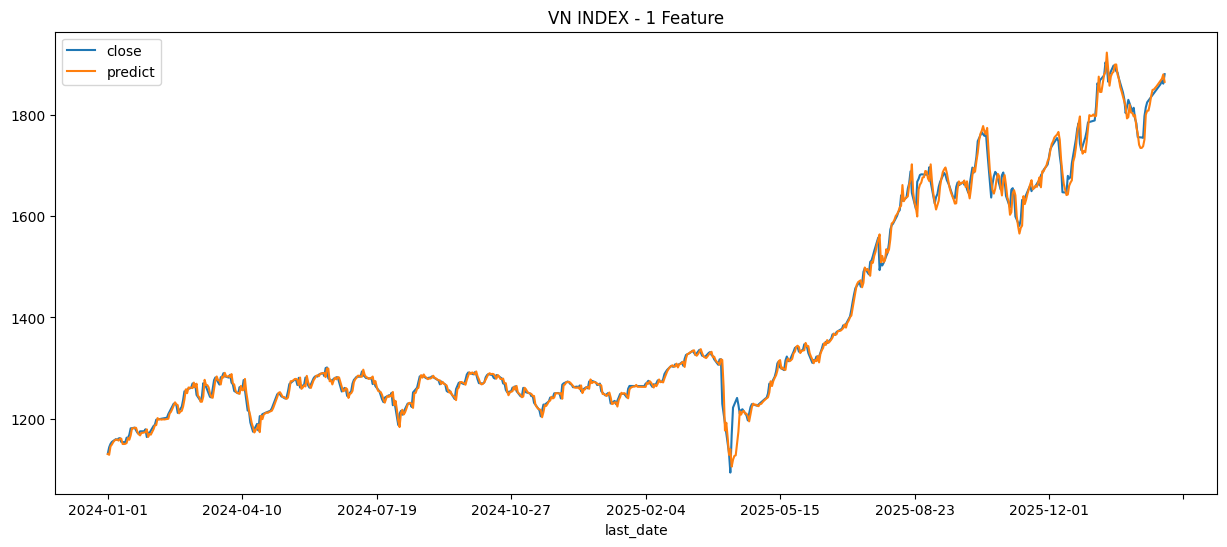

In [1051]:
plt.figure(figsize=(15, 6))
plt.title("VN INDEX - 1 Feature")

y_test.plot(ax=plt.gca(), legend="close")
y_predict_plot.plot(ax=plt.gca(), legend="predict", marker=None)

plt.show()

In [1052]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

# Convert to numpy arrays (flatten in case they are DataFrames)
y_true = y_test.values.flatten()
y_pred = y_predict_plot.values.flatten()

In [1053]:
# 1️⃣ MSE (Mean Squared Error)
mse = mean_squared_error(y_true, y_pred)

# 2️⃣ MAPE (Mean Absolute Percentage Error)
# Avoid division by zero
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# 3️⃣ RMSSE (Root Mean Squared Scaled Error)
# RMSSE needs scaling by naive forecast (lag-1)
# denominator = mean squared difference of actuals
denominator = np.mean(np.diff(y_true) ** 2)
rmsse = np.sqrt(mse / denominator)

print(f"MSE: {mse:.4f}")
print(f"MAPE: {mape:.4f} %")
print(f"RMSSE: {rmsse:.4f}")

MSE: 206.9672
MAPE: 0.5856 %
RMSSE: 1.2579


### Predict

In [1054]:
# Get last row and keep 2D shape
last_row = X_test_scaler[-1:]
last_row.shape

(1, 159)

In [1055]:
# Convert to tensor
last_row_tensor = torch.tensor(last_row, dtype=torch.float32)

with torch.no_grad():
    y_pred = model(last_row_tensor)

y_pred_inverse = y_scaler.inverse_transform(y_pred.cpu().numpy().reshape(-1, 1))

y_predict = pd.DataFrame(
    y_pred_inverse, index=[X_test_selected.index[-1]], columns=["predict"]
)

y_predict.squeeze()

1864.3855

### Save data

In [1056]:
import os
import sys
import pickle
import ipynbname
from torch.utils.tensorboard import SummaryWriter

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from utils.utils import get_current_run_path, save_prediction_figure

result_folder = get_current_run_path()

NB_NAME = ipynbname.name()

# -----------------------
# Save model
# -----------------------
pickle_path = os.path.join(result_folder, "model.pkl")
with open(pickle_path, "wb") as f:
    pickle.dump(model, f)

# -----------------------
# Save prediction figure
# -----------------------
fig_path = os.path.join(result_folder, f"{NB_NAME}.jpg")

save_prediction_figure(
    y_test=y_test, y_predict=y_predict_plot, save_path=fig_path, title=f"{NB_NAME}"
)

writer = SummaryWriter(result_folder)

writer.add_scalar("Metrics/MSE", mse, 0)
writer.add_scalar("Metrics/MAPE", mape, 0)
writer.add_scalar("Metrics/RMSSE", rmsse, 0)

writer.close()

print(f"Saved results to: {result_folder}")

Saved results to: lightning_logs\version_15
